In [ ]:
!pip install catboost lightgbm xgboost optuna shap --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 36.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import warnings, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
import shap

print("Libraries loaded.")

Libraries loaded.


In [ ]:
# Change this in all notebooks:
# Make sure to upload 'train_cleaned.csv' and 'test_cleaned.csv' to your Colab environment
# or mount Google Drive and specify the correct path.
train_df = pd.read_csv("train_cleaned.csv")
test_df  = pd.read_csv("test_cleaned.csv")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Target distribution:")
print(train_df["experience_difference"].describe())

Train shape: (24010, 22)
Test shape : (19960, 22)
Target distribution:
count    24009.000000
mean         3.808988
std          4.125933
min         -4.000000
25%          0.000000
50%          4.000000
75%          7.000000
max         13.000000
Name: experience_difference, dtype: float64


In [ ]:
TARGET    = "experience_difference"
DROP_COLS = ["application_id","candidate_id","job_id","name","email","label","status"]

def preprocess(df, target):
    df = df.copy()
    for col in DROP_COLS:
        if col in df.columns:
            df.drop(columns=col, inplace=True)
    for col in df.columns:
        if col == target:
            continue
        if df[col].dtype == object:
            df[col].fillna("Unknown", inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
    # Date features
    for col in df.select_dtypes(include="object").columns:
        if col == target:
            continue
        try:
            parsed = pd.to_datetime(df[col], errors="raise")
            df[col + "_year"]       = parsed.dt.year
            df[col + "_month"]      = parsed.dt.month
            df[col + "_weekday"]    = parsed.dt.weekday
            df[col + "_quarter"]    = parsed.dt.quarter
            df[col + "_is_weekend"] = (parsed.dt.weekday >= 5).astype(int)
            df.drop(columns=col, inplace=True)
            print(f"Date-encoded: {col}")
        except Exception:
            pass
    for col in df.select_dtypes(include="object").columns:
        if col != target:
            df[col] = df[col].astype(str)
    return df

train_df = preprocess(train_df, TARGET)
test_df  = preprocess(test_df,  TARGET)

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET].values
X_test  = test_df.drop(columns=TARGET)
y_test  = test_df[TARGET].values

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]
print(f"Categorical features ({len(cat_cols)}):", cat_cols)
print(f"X_train shape: {X_train.shape}")

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[cat_cols] = oe.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols]  = oe.transform(X_test[cat_cols])

Date-encoded: application_date
Date-encoded: application_date
Categorical features (5): ['skills', 'education', 'projects', 'role', 'required_skills']
X_train shape: (24010, 18)


In [ ]:
baseline_cb = CatBoostRegressor(
    iterations=200, learning_rate=0.05, depth=6,
    random_seed=42, verbose=0
)

# Identify NaN values in y_train
nan_in_y_train_mask = np.isnan(y_train)

# Filter X_train and y_train to remove rows where y_train is NaN
X_train_filtered = X_train[~nan_in_y_train_mask]
y_train_filtered = y_train[~nan_in_y_train_mask]

baseline_cb.fit(X_train_filtered, y_train_filtered, cat_features=cat_idx)
bp = baseline_cb.predict(X_test)
print(f"Baseline — MAE: {mean_absolute_error(y_test,bp):.4f}  "
      f"RMSE: {mean_squared_error(y_test,bp)**0.5:.4f}  "
      f"R2: {r2_score(y_test,bp):.4f}")

Baseline — MAE: 0.0326  RMSE: 0.0506  R2: 0.9998


In [ ]:
def cb_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 200, 800),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_seed": 42, "verbose": 0, "thread_count": -1
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmses = []
    # Use the filtered data for cross-validation
    for tr, val in kf.split(X_train_filtered):
        m = CatBoostRegressor(**params)
        m.fit(X_train_filtered.iloc[tr], y_train_filtered[tr],
              cat_features=cat_idx,
              eval_set=(X_train_filtered.iloc[val], y_train_filtered[val]),
              early_stopping_rounds=20, verbose=0)
        p = m.predict(X_train_filtered.iloc[val])
        rmses.append(mean_squared_error(y_train_filtered[val], p)**0.5)
    return np.mean(rmses)

cb_study = optuna.create_study(direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True)
print("Best CV RMSE (CatBoost):", round(cb_study.best_value, 4))
print("Best params:", cb_study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV RMSE (CatBoost): 0.0069
Best params: {'iterations': 791, 'learning_rate': 0.14680144113042604, 'depth': 7, 'l2_leaf_reg': 9.978810901365721, 'border_count': 164, 'bagging_temperature': 0.038513608948596276}


In [ ]:
# Filter X_train_enc to match y_train_filtered
X_train_enc_filtered = X_train_enc[~nan_in_y_train_mask]

def lgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42, "verbose": -1
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmses = []
    # Use the filtered data for cross-validation
    for tr, val in kf.split(X_train_enc_filtered):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train_enc_filtered.iloc[tr], y_train_filtered[tr])
        p = m.predict(X_train_enc_filtered.iloc[val])
        rmses.append(mean_squared_error(y_train_filtered[val], p)**0.5)
    return np.mean(rmses)

lgb_study = optuna.create_study(direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print("Best CV RMSE (LightGBM):", round(lgb_study.best_value, 4))

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV RMSE (LightGBM): 0.0054


In [ ]:
def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "eval_metric": "rmse", "verbosity": 0, "random_state": 42
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmses = []
    # Use the filtered data for cross-validation
    for tr, val in kf.split(X_train_enc_filtered):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train_enc_filtered.iloc[tr], y_train_filtered[tr], verbose=False)
        p = m.predict(X_train_enc_filtered.iloc[val])
        rmses.append(mean_squared_error(y_train_filtered[val], p)**0.5)
    return np.mean(rmses)

xgb_study = optuna.create_study(direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print("Best CV RMSE (XGBoost):", round(xgb_study.best_value, 4))

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV RMSE (XGBoost): 0.0172


In [ ]:
cb_params = {**cb_study.best_params, "random_seed": 42, "verbose": 100, "thread_count": -1}
tuned_cb = CatBoostRegressor(**cb_params)
tuned_cb.fit(X_train_filtered, y_train_filtered, cat_features=cat_idx,
             eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_pred = tuned_cb.predict(X_test)

lgb_params = {**lgb_study.best_params, "random_state": 42, "verbose": -1}
tuned_lgb = lgb.LGBMRegressor(**lgb_params)
tuned_lgb.fit(X_train_enc_filtered, y_train_filtered)
lgb_pred = tuned_lgb.predict(X_test_enc)

xgb_params = {**xgb_study.best_params, "eval_metric": "rmse", "verbosity": 0, "random_state": 42}
tuned_xgb = xgb.XGBRegressor(**xgb_params)
tuned_xgb.fit(X_train_enc_filtered, y_train_filtered)
xgb_pred = tuned_xgb.predict(X_test_enc)

def reg_metrics(name, yt, yp):
    print(f"{name:<25} MAE={mean_absolute_error(yt,yp):.4f}  "
          f"RMSE={mean_squared_error(yt,yp)**0.5:.4f}  R2={r2_score(yt,yp):.4f}")

reg_metrics("Baseline CatBoost",  y_test, bp)
reg_metrics("Tuned CatBoost",     y_test, cb_pred)
reg_metrics("Tuned LightGBM",     y_test, lgb_pred)
reg_metrics("Tuned XGBoost",      y_test, xgb_pred)

0:	learn: 3.5717567	test: 3.4866417	best: 3.4866417 (0)	total: 40ms	remaining: 31.6s
100:	learn: 0.0421838	test: 0.0356702	best: 0.0356680 (98)	total: 3.95s	remaining: 27s
200:	learn: 0.0218394	test: 0.0174678	best: 0.0174678 (200)	total: 10.9s	remaining: 32s
300:	learn: 0.0155123	test: 0.0120490	best: 0.0120490 (300)	total: 14.6s	remaining: 23.8s
400:	learn: 0.0122652	test: 0.0092892	best: 0.0092891 (398)	total: 18.1s	remaining: 17.6s
500:	learn: 0.0106523	test: 0.0080242	best: 0.0080242 (500)	total: 22.5s	remaining: 13s
600:	learn: 0.0091343	test: 0.0068770	best: 0.0068762 (598)	total: 26.7s	remaining: 8.43s
700:	learn: 0.0081028	test: 0.0060639	best: 0.0060639 (699)	total: 30.5s	remaining: 3.92s
790:	learn: 0.0074832	test: 0.0055879	best: 0.0055879 (790)	total: 34.6s	remaining: 0us

bestTest = 0.00558794591
bestIteration = 790

Baseline CatBoost         MAE=0.0326  RMSE=0.0506  R2=0.9998
Tuned CatBoost            MAE=0.0037  RMSE=0.0056  R2=1.0000
Tuned LightGBM            MAE=0.000

In [ ]:
w_cb  = 1 / cb_study.best_value
w_lgb = 1 / lgb_study.best_value
w_xgb = 1 / xgb_study.best_value
w_sum = w_cb + w_lgb + w_xgb

ensemble_pred = (w_cb*cb_pred + w_lgb*lgb_pred + w_xgb*xgb_pred) / w_sum

mae  = mean_absolute_error(y_test, ensemble_pred)
rmse = mean_squared_error(y_test, ensemble_pred)**0.5
r2   = r2_score(y_test, ensemble_pred)

print(f"Weights — CB: {w_cb/w_sum:.3f}  LGB: {w_lgb/w_sum:.3f}  XGB: {w_xgb/w_sum:.3f}")
print(f"Ensemble — MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}")

if r2 >= 0.90:
    print(f"\n TARGET MET! R2={r2:.4f}")
else:
    print(f"\n Best R2={r2:.4f}")

Weights — CB: 0.374  LGB: 0.476  XGB: 0.150
Ensemble — MAE: 0.0033  RMSE: 0.0061  R2: 1.0000

 TARGET MET! R2=1.0000


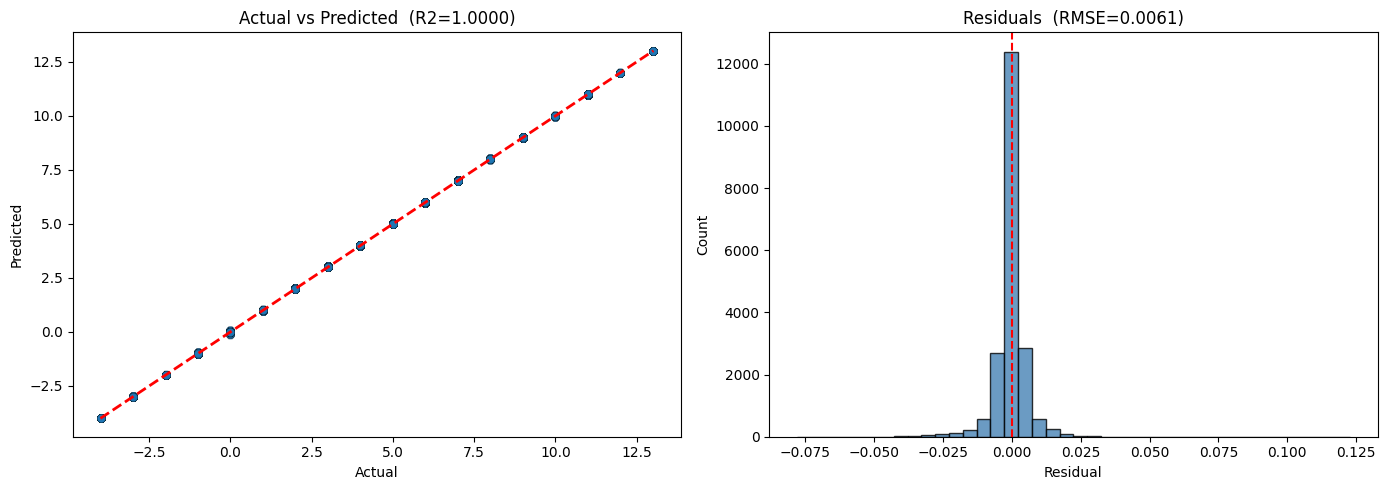

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, ensemble_pred, alpha=0.3, edgecolors="k", linewidths=0.2)
lims = [min(y_test.min(), ensemble_pred.min()), max(y_test.max(), ensemble_pred.max())]
axes[0].plot(lims, lims, "r--", lw=2)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted  (R2={r2:.4f})")

residuals = y_test - ensemble_pred
axes[1].hist(residuals, bins=40, edgecolor="k", color="steelblue", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals  (RMSE={rmse:.4f})")

plt.tight_layout(); plt.show()

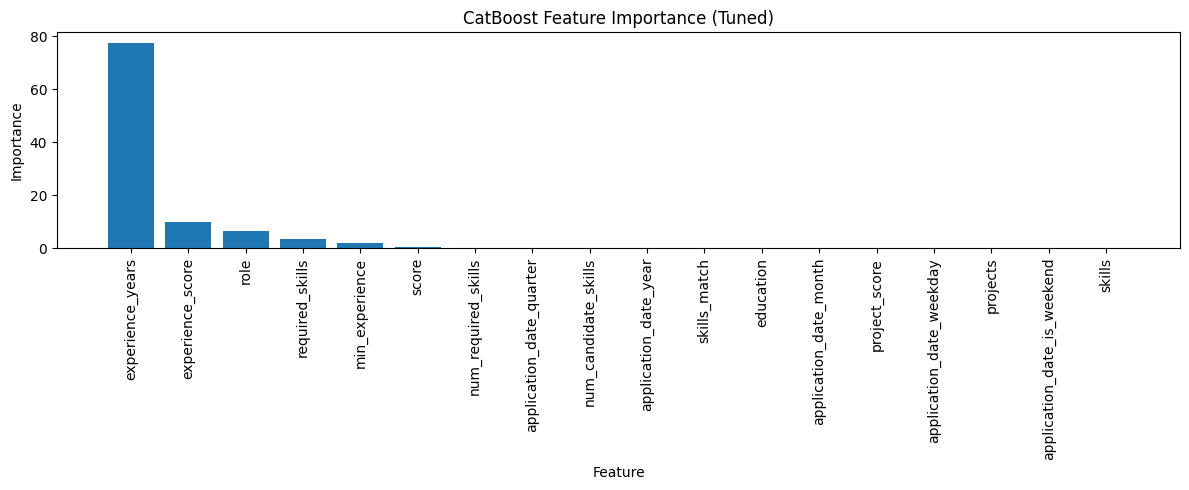

Top Strengths: ['experience_years', 'experience_score', 'role']
Top Gaps:      ['projects', 'application_date_is_weekend', 'skills']


In [ ]:
imp = tuned_cb.get_feature_importance()
importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": imp})\
               .sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=90)
plt.xlabel("Feature"); plt.ylabel("Importance")
plt.title("CatBoost Feature Importance (Tuned)")
plt.tight_layout(); plt.show()

top_strengths = importance_df["Feature"].head(3).tolist()
top_gaps      = importance_df["Feature"].tail(3).tolist()
print("Top Strengths:", top_strengths)
print("Top Gaps:     ", top_gaps)

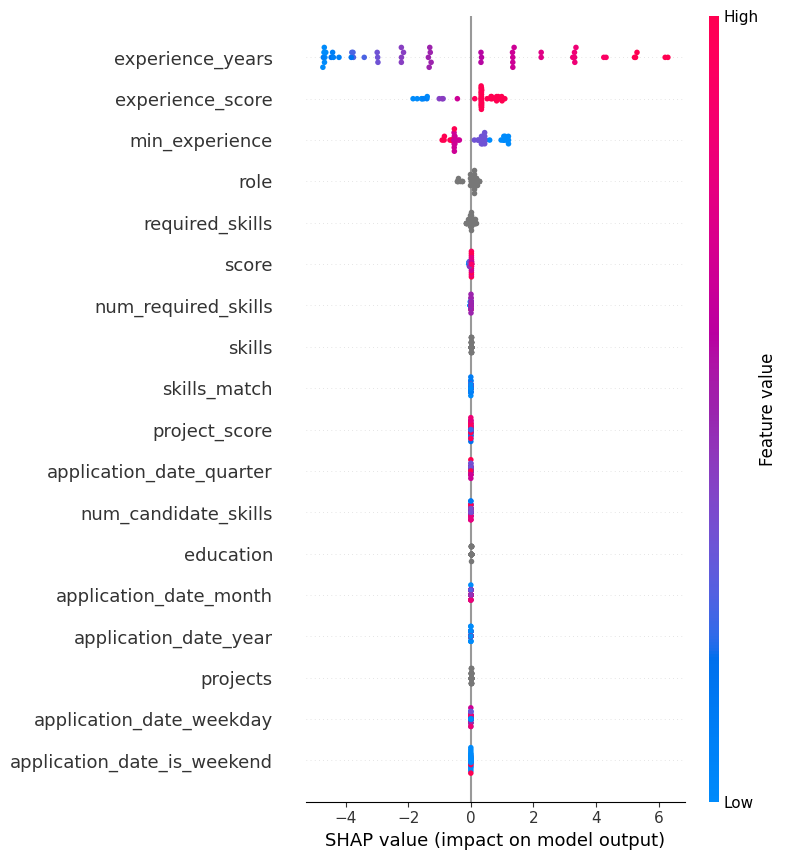

In [ ]:
sample_data     = X_test.head(50)
sample_data_enc = X_test_enc.head(50)

cb_explainer  = shap.TreeExplainer(tuned_cb)
lgb_explainer = shap.TreeExplainer(tuned_lgb)
xgb_explainer = shap.TreeExplainer(tuned_xgb)

cb_shap  = cb_explainer.shap_values(sample_data)
lgb_shap = lgb_explainer.shap_values(sample_data_enc)
xgb_shap = xgb_explainer.shap_values(sample_data_enc)

ensemble_shap = (w_cb*np.array(cb_shap) + w_lgb*np.array(lgb_shap) + w_xgb*np.array(xgb_shap)) / w_sum

shap.summary_plot(ensemble_shap, sample_data, feature_names=X_train.columns.tolist())

In [ ]:
explanation_payload = {
    "candidate_id":          101,
    "predicted_exp_gap":     float(round(ensemble_pred[0], 2)),
    "actual_exp_gap":        float(y_test[0]),
    "model_metrics":         {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)},
    "ensemble_weights":      {"CatBoost": round(w_cb/w_sum,3), "LightGBM": round(w_lgb/w_sum,3), "XGBoost": round(w_xgb/w_sum,3)},
    "top_strengths":         top_strengths,
    "top_gaps":              top_gaps,
    "feature_importance":    importance_df.head(5).to_dict(orient="records")
}
print(json.dumps(explanation_payload, indent=2))

{
  "candidate_id": 101,
  "predicted_exp_gap": 8.99,
  "actual_exp_gap": 9.0,
  "model_metrics": {
    "MAE": 0.0033,
    "RMSE": 0.0061,
    "R2": 1.0
  },
  "ensemble_weights": {
    "CatBoost": 0.374,
    "LightGBM": 0.476,
    "XGBoost": 0.15
  },
  "top_strengths": [
    "experience_years",
    "experience_score",
    "role"
  ],
  "top_gaps": [
    "projects",
    "application_date_is_weekend",
    "skills"
  ],
  "feature_importance": [
    {
      "Feature": "experience_years",
      "Importance": 77.60843761882246
    },
    {
      "Feature": "experience_score",
      "Importance": 10.03500046953143
    },
    {
      "Feature": "role",
      "Importance": 6.313384277141072
    },
    {
      "Feature": "required_skills",
      "Importance": 3.53973103790976
    },
    {
      "Feature": "min_experience",
      "Importance": 1.9969137428191253
    }
  ]
}


In [ ]:
tuned_cb.save_model("catboost_candidates_best.cbm")
print("Model saved to catboost_candidates_best.cbm")

Model saved to catboost_candidates_best.cbm


In [ ]:
import pickle

# Save all models and encoders as pkl
with open("candidates_catboost_model.pkl",    "wb") as f: pickle.dump(tuned_cb,  f)
with open("candidates_lgbm_model.pkl",        "wb") as f: pickle.dump(tuned_lgb, f)
with open("candidates_xgboost_model.pkl",     "wb") as f: pickle.dump(tuned_xgb, f)
with open("candidates_ordinal_encoder.pkl",   "wb") as f: pickle.dump(oe, f)
with open("candidates_ensemble_weights.pkl",  "wb") as f: pickle.dump({"w_cb": w_cb, "w_lgb": w_lgb, "w_xgb": w_xgb, "w_sum": w_sum}, f)

print("✅ All candidates pkl files saved!")
print("  candidates_catboost_model.pkl")
print("  candidates_lgbm_model.pkl")
print("  candidates_xgboost_model.pkl")
print("  candidates_ordinal_encoder.pkl")
print("  candidates_ensemble_weights.pkl")

# Download all pkl files
from google.colab import files
files.download("candidates_catboost_model.pkl")
files.download("candidates_lgbm_model.pkl")
files.download("candidates_xgboost_model.pkl")
files.download("candidates_ordinal_encoder.pkl")
files.download("candidates_ensemble_weights.pkl")
